In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import ttest_ind, f_oneway
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline

In [2]:
data = pd.read_csv('dataset.csv')

In [3]:
climate_columns = [
    'Average_Temperature_C',
    'Annual_Rainfall_mm',
    'Extreme_Weather_Events',
    'Soil_Moisture_Percentage',
    'Crop_Yield_ton_per_hectare'
]

# Compute correlation matrix
correlation_matrix = data[climate_columns].corr()
correlation_matrix

,Average_Temperature_C,Annual_Rainfall_mm,Extreme_Weather_Events,Soil_Moisture_Percentage,Crop_Yield_ton_per_hectare
Average_Temperature_C,1.000000,-0.987616,0.979012,-0.994690,-0.998209
Annual_Rainfall_mm,-0.987616,1.000000,-0.979372,0.996912,0.980274
Extreme_Weather_Events,0.979012,-0.979372,1.000000,-0.982614,-0.975854
Soil_Moisture_Percentage,-0.994690,0.996912,-0.982614,1.000000,0.990485
Crop_Yield_ton_per_hectare,-0.998209,0.980274,-0.975854,0.990485,1.000000


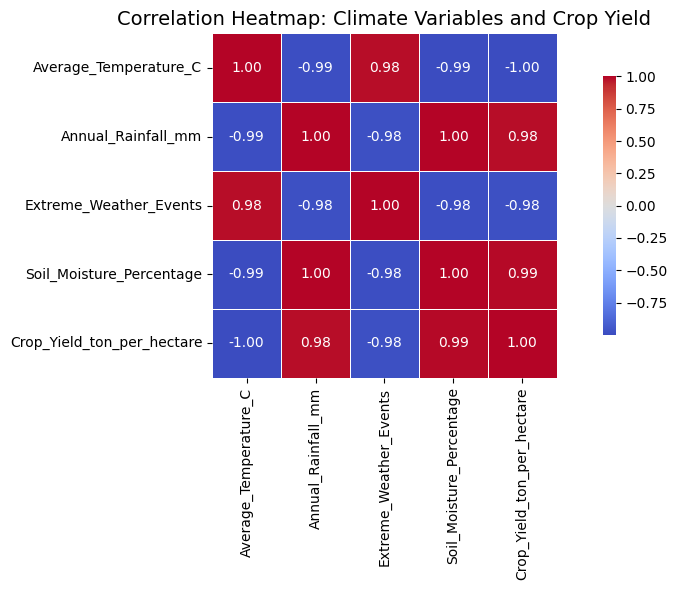

In [4]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,               # Annotate with correlation values
    fmt=".2f",                # Format to 2 decimal places
    cmap='coolwarm',          # Color scheme
    linewidths=0.5,           # Lines between cells
    square=True,              # Square cells for aesthetics
    cbar_kws={"shrink": .75}  # Shrink color bar a bit
)

plt.title('Correlation Heatmap: Climate Variables and Crop Yield', fontsize=14)
plt.tight_layout()
plt.show()

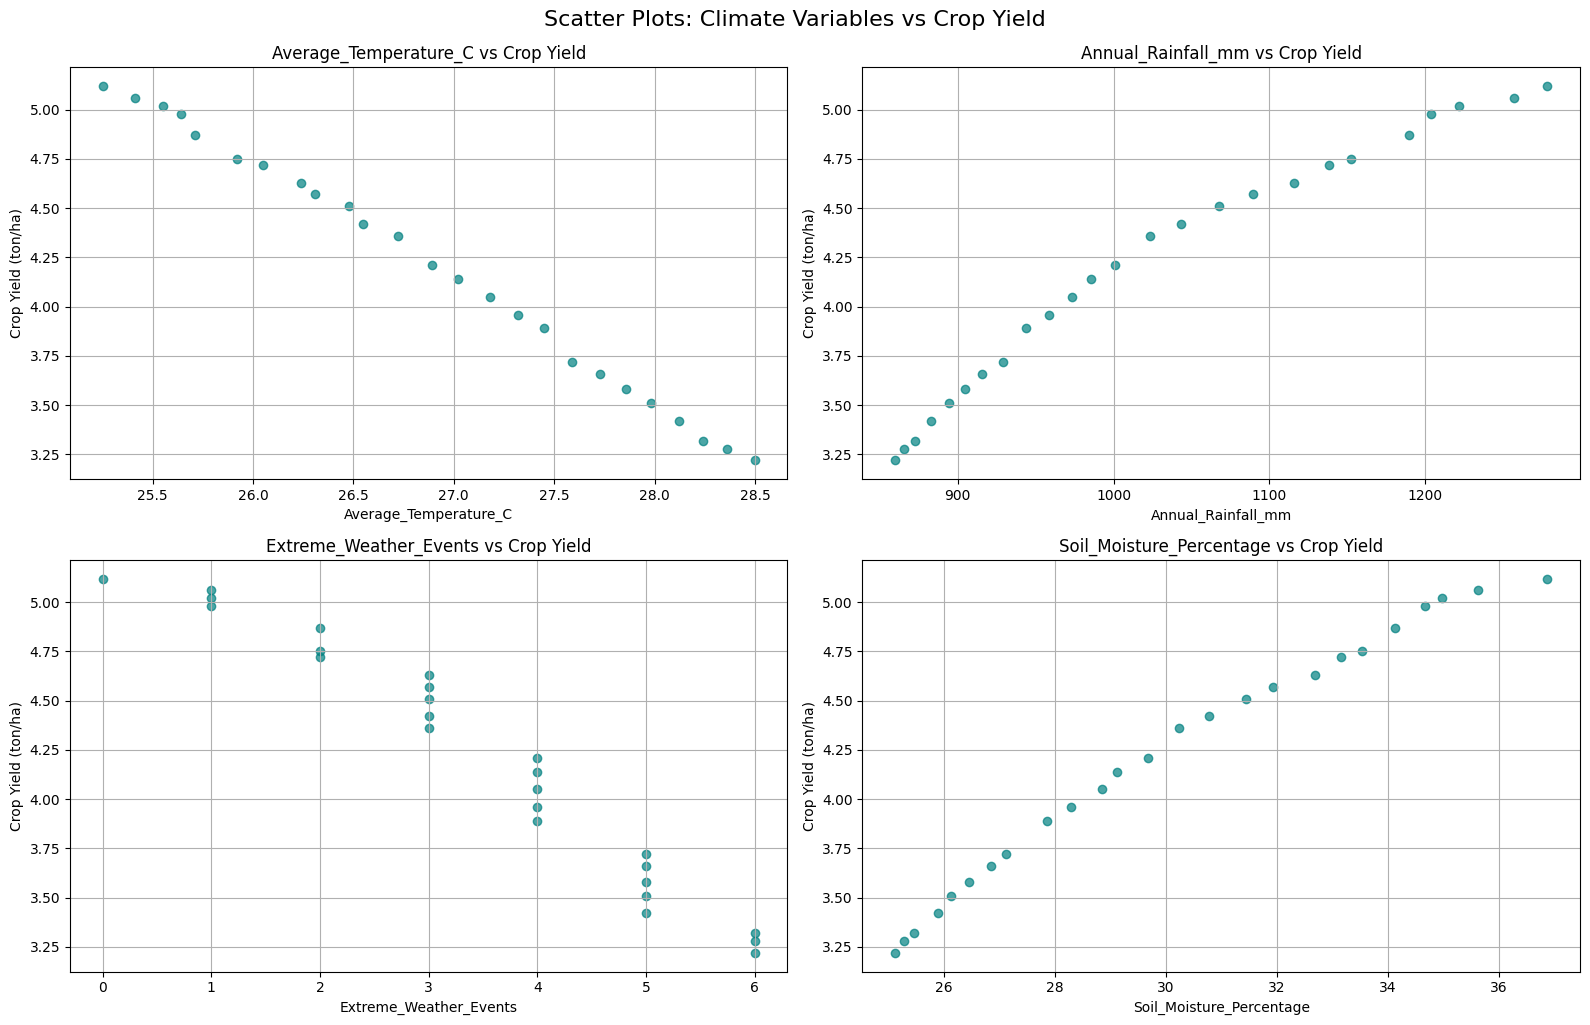

In [5]:
variables = [
    'Average_Temperature_C',
    'Annual_Rainfall_mm',
    'Extreme_Weather_Events',
    'Soil_Moisture_Percentage'
]

# Create subplots
plt.figure(figsize=(16, 10))
for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i)
    plt.scatter(data[var], data['Crop_Yield_ton_per_hectare'], alpha=0.7, color='teal')
    plt.title(f'{var} vs Crop Yield')
    plt.xlabel(var)
    plt.ylabel('Crop Yield (ton/ha)')
    plt.grid(True)

plt.tight_layout()
plt.suptitle('Scatter Plots: Climate Variables vs Crop Yield', fontsize=16, y=1.02)
plt.show()

In [6]:
# ---------------------------------------
# Hypotheses for ANOVA:
# H0 (Null Hypothesis): There is no significant difference in crop yield across different levels of extreme weather events.
# H1 (Alternative Hypothesis): There is a significant difference in crop yield across different levels of extreme weather events.
# ---------------------------------------

# Group crop yields based on unique extreme weather event counts
unique_events = sorted(data['Extreme_Weather_Events'].unique())
grouped_yields = [data[data['Extreme_Weather_Events'] == val]['Crop_Yield_ton_per_hectare'] for val in unique_events]

# Perform one-way ANOVA
anova_result = f_oneway(*grouped_yields)

print("ANOVA Test Results:")
print("F-statistic:", round(anova_result.statistic, 4))
print("p-value:", format(anova_result.pvalue, ".4e"))

if anova_result.pvalue < 0.05:
    print("Result: Reject the null hypothesis — significant difference in crop yield based on extreme weather events.\n")
else:
    print("Result: Fail to reject the null hypothesis — no significant difference in crop yield based on extreme weather events.\n")

# ---------------------------------------
# Hypotheses for T-test (0 events vs. 1+ events):
# H0: There is no significant difference in crop yield between years with 0 events and years with 1+ events.
# H1: There is a significant difference in crop yield between years with 0 events and years with 1+ events.
# ---------------------------------------

# Create two groups
yield_no_events = data[data['Extreme_Weather_Events'] == 0]['Crop_Yield_ton_per_hectare']
yield_with_events = data[data['Extreme_Weather_Events'] > 0]['Crop_Yield_ton_per_hectare']

# Check if both groups have enough variation
if yield_no_events.nunique() > 1 and yield_with_events.nunique() > 1:
    t_test_result = ttest_ind(yield_no_events, yield_with_events, equal_var=False)
    print("T-test Results:")
    print("T-statistic:", round(t_test_result.statistic, 4))
    print("p-value:", format(t_test_result.pvalue, ".4e"))
    
    if t_test_result.pvalue < 0.05:
        print("Result: Reject the null hypothesis — significant difference in crop yield between 0 and 1+ extreme events.")
    else:
        print("Result: Fail to reject the null hypothesis — no significant difference in crop yield between 0 and 1+ extreme events.")
else:
    print("T-test could not be performed reliably due to lack of variability in one or both groups.")


ANOVA Test Results:
F-statistic: 139.2305
p-value: 4.3739e-14
Result: Reject the null hypothesis — significant difference in crop yield based on extreme weather events.

T-test could not be performed reliably due to lack of variability in one or both groups.


In [7]:
# Define a function to perform ANOVA and T-test with hypothesis explanation
def perform_tests(df, variable, threshold=None):
    print(f"--- Analyzing {variable} vs Crop Yield ---")
    
    # Create bins for the variable
    if threshold is None:
        # Use median to split into two groups for t-test
        threshold = df[variable].median()

    # Define high and low groups based on threshold
    group_low = df[df[variable] <= threshold]['Crop_Yield_ton_per_hectare']
    group_high = df[df[variable] > threshold]['Crop_Yield_ton_per_hectare']

    # ANOVA using quartiles
    df['category'] = pd.qcut(df[variable], q=4, duplicates='drop')
    grouped = df.groupby('category')['Crop_Yield_ton_per_hectare'].apply(list)

    # ANOVA
    anova = f_oneway(*grouped)
    print("\nANOVA Test:")
    print(f"H0: No significant difference in crop yield across different levels of {variable}")
    print(f"H1: Significant difference in crop yield across different levels of {variable}")
    print("F-statistic:", round(anova.statistic, 4))
    print("p-value:", format(anova.pvalue, ".4e"))
    if anova.pvalue < 0.05:
        print("Result: Reject H0 — significant difference\n")
    else:
        print("Result: Fail to reject H0 — not significant\n")

    # T-Test
    if group_low.nunique() > 1 and group_high.nunique() > 1:
        t_test = ttest_ind(group_low, group_high, equal_var=False)
        print("T-test:")
        print(f"H0: No significant difference in crop yield between low and high {variable}")
        print(f"H1: Significant difference in crop yield between low and high {variable}")
        print("T-statistic:", round(t_test.statistic, 4))
        print("p-value:", format(t_test.pvalue, ".4e"))
        if t_test.pvalue < 0.05:
            print("Result: Reject H0 — significant difference\n")
        else:
            print("Result: Fail to reject H0 — not significant\n")
    else:
        print("T-test: Could not be performed due to insufficient variation in groups.\n")

# Variables to analyze
variables = ['Average_Temperature_C', 'Annual_Rainfall_mm', 'Soil_Moisture_Percentage']

# Run the tests for each variable
for var in variables:
    perform_tests(data.copy(), var)


--- Analyzing Average_Temperature_C vs Crop Yield ---

ANOVA Test:
H0: No significant difference in crop yield across different levels of Average_Temperature_C
H1: Significant difference in crop yield across different levels of Average_Temperature_C
F-statistic: 113.2313
p-value: 3.9771e-13
Result: Reject H0 — significant difference

T-test:
H0: No significant difference in crop yield between low and high Average_Temperature_C
H1: Significant difference in crop yield between low and high Average_Temperature_C
T-statistic: 8.8152
p-value: 9.5233e-09
Result: Reject H0 — significant difference

--- Analyzing Annual_Rainfall_mm vs Crop Yield ---

ANOVA Test:
H0: No significant difference in crop yield across different levels of Annual_Rainfall_mm
H1: Significant difference in crop yield across different levels of Annual_Rainfall_mm
F-statistic: 121.0655
p-value: 2.0533e-13
Result: Reject H0 — significant difference

T-test:
H0: No significant difference in crop yield between low and high A

C:\Users\Soumya Chanda\AppData\Local\Temp\ipykernel_18236\2354741090.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('category')['Crop_Yield_ton_per_hectare'].apply(list)
C:\Users\Soumya Chanda\AppData\Local\Temp\ipykernel_18236\2354741090.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('category')['Crop_Yield_ton_per_hectare'].apply(list)
C:\Users\Soumya Chanda\AppData\Local\Temp\ipykernel_18236\2354741090.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retai